In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
import geopandas as gpd
from shapely.geometry import Point, LineString
import os
from pathlib import Path
import contextily as cx
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter

In [9]:
gravity_path = "../../data/gravity/raw_data/gps_data/gravity_05_27_2026.csv"

gravity_df = pd.read_csv(gravity_path)

print("Gravity data shape:", gravity_df.shape)
print(gravity_df.columns)
gravity_df.head(2)

Gravity data shape: (33, 40)
Index(['Name', 'Code', 'Code description', 'Easting', 'Northing', 'Elevation',
       'Description', 'Longitude', 'Latitude', 'Ellipsoidal height', 'Origin',
       'Easting RMS', 'Northing RMS', 'Elevation RMS', 'Lateral RMS',
       'Antenna height', 'Antenna height units', 'Solution status',
       'Correction type', 'Averaging start', 'Averaging end', 'Samples',
       'PDOP', 'GDOP', 'Base easting', 'Base northing', 'Base elevation',
       'Base longitude', 'Base latitude', 'Base ellipsoidal height',
       'Baseline', 'Mount point', 'CS name', 'GPS Satellites',
       'GLONASS Satellites', 'Galileo Satellites', 'BeiDou Satellites',
       'QZSS Satellites', 'Device type', 'Device serial number'],
      dtype='object')


,Name,Code,Code description,Easting,Northing,Elevation,Description,Longitude,Latitude,Ellipsoidal height,...,Baseline,Mount point,CS name,GPS Satellites,GLONASS Satellites,Galileo Satellites,BeiDou Satellites,QZSS Satellites,Device type,Device serial number
0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,-106.835552,40.478911,2109.865,...,NaN,NaN,Global CS,NaN,NaN,NaN,NaN,NaN,Reach RS3,824394D6A0F52E01
1,28.0,NaN,NaN,NaN,NaN,NaN,NaN,-106.835549,40.478904,2109.904,...,NaN,NaN,Global CS,NaN,NaN,NaN,NaN,NaN,Reach RS3,824394D6A0F52E01


In [10]:
plt.figure(figsize=(4, 4))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    s=20
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Point Locations")
plt.grid(True)

plt.show()

NameError: name 'df' is not defined

<Figure size 400x400 with 0 Axes>

In [12]:
gravity_gps = gravity_df[["Name", "Longitude", "Latitude", "Ellipsoidal height"]].copy()

gravity_gps = gravity_gps.rename(columns={
    "Name": "station",
    "Ellipsoidal height": "elevation_m"
})

gravity_gps.head()

,station,Longitude,Latitude,elevation_m
0,29.0,-106.835552,40.478911,2109.865
1,28.0,-106.835549,40.478904,2109.904
2,27.0,-106.835548,40.478896,2110.327
3,26.0,-106.835546,40.478888,2110.143
4,25.0,-106.835543,40.478878,2110.270


In [13]:
poi_path = "../../data/GPR/raw_data/GPS_Emlid/group2_onyx_mine.csv"

poi_df = pd.read_csv(poi_path)

print("POI data shape:", poi_df.shape)
print(poi_df.columns)
poi_df.head()

POI data shape: (3, 40)
Index(['Name', 'Code', 'Code description', 'Easting', 'Northing', 'Elevation',
       'Description', 'Longitude', 'Latitude', 'Ellipsoidal height', 'Origin',
       'Easting RMS', 'Northing RMS', 'Elevation RMS', 'Lateral RMS',
       'Antenna height', 'Antenna height units', 'Solution status',
       'Correction type', 'Averaging start', 'Averaging end', 'Samples',
       'PDOP', 'GDOP', 'Base easting', 'Base northing', 'Base elevation',
       'Base longitude', 'Base latitude', 'Base ellipsoidal height',
       'Baseline', 'Mount point', 'CS name', 'GPS Satellites',
       'GLONASS Satellites', 'Galileo Satellites', 'BeiDou Satellites',
       'QZSS Satellites', 'Device type', 'Device serial number'],
      dtype='object')


,Name,Code,Code description,Easting,Northing,Elevation,Description,Longitude,Latitude,Ellipsoidal height,...,Baseline,Mount point,CS name,GPS Satellites,GLONASS Satellites,Galileo Satellites,BeiDou Satellites,QZSS Satellites,Device type,Device serial number
0,test pit,NaN,NaN,344414.390,4482538.484,2109.945,NaN,-106.835545,40.478969,2109.945,...,21.856,NaN,WGS 84 / UTM zone 13N,8,4,9,6,0,Reach RS3,82437308b6c6ad5b
1,small mine entrance,NaN,NaN,344424.297,4482539.231,2108.073,NaN,-106.835428,40.478978,2108.073,...,27.864,NaN,WGS 84 / UTM zone 13N,8,4,9,6,0,Reach RS3,82437308b6c6ad5b
2,above big entrance to mine,NaN,NaN,344429.718,4482525.846,2108.577,NaN,-106.835361,40.478858,2108.577,...,41.158,NaN,WGS 84 / UTM zone 13N,8,4,9,6,0,Reach RS3,82437308b6c6ad5b


In [14]:
poi_gps = poi_df[["Name", "Longitude", "Latitude", "Elevation", "Ellipsoidal height"]].copy()

poi_gps = poi_gps.rename(columns={
    "Name": "point_name",
    "Elevation": "elevation_m",
    "Ellipsoidal height": "ellipsoidal_height_m"
})

poi_gps.head()

,point_name,Longitude,Latitude,elevation_m,ellipsoidal_height_m
0,test pit,-106.835545,40.478969,2109.945,2109.945
1,small mine entrance,-106.835428,40.478978,2108.073,2108.073
2,above big entrance to mine,-106.835361,40.478858,2108.577,2108.577


In [15]:
#seismic_endpoints = pd.DataFrame({
 #   "station_m": [0, 94],
  #  "easting": [344505, 344495],
   # "northing": [4482779, 4482781],
   # "utm_zone": ["13T", "13T"]
#})

#seismic_endpoints





seismic_endpoints = pd.DataFrame({
    "station_m": [0, 94],
    "easting": [344505, 344413],
    "northing": [4482779, 4482829],
    "utm_zone": ["13T", "13T"]
})

seismic_endpoints
#94m: 40.481587, -106.835628

,station_m,easting,northing,utm_zone
0,0,344505,4482779,13T
1,94,344413,4482829,13T


In [16]:
gravity_gdf = gpd.GeoDataFrame(
    gravity_gps,
    geometry=gpd.points_from_xy(gravity_gps["Longitude"], gravity_gps["Latitude"]),
    crs="EPSG:4326"
)

poi_gdf = gpd.GeoDataFrame(
    poi_gps,
    geometry=gpd.points_from_xy(poi_gps["Longitude"], poi_gps["Latitude"]),
    crs="EPSG:4326"
)

In [17]:
seismic_gdf = gpd.GeoDataFrame(
    seismic_endpoints,
    geometry=gpd.points_from_xy(seismic_endpoints["easting"], seismic_endpoints["northing"]),
    crs="EPSG:32613"
)

# Convert seismic points to lat/lon so all raw GPS layers match
seismic_gdf_latlon = seismic_gdf.to_crs(epsg=4326)

seismic_gdf_latlon

,station_m,easting,northing,utm_zone,geometry
0,0,344505,4482779,13T,POINT (-106.83454 40.48115)
1,94,344413,4482829,13T,POINT (-106.83563 40.48158)


In [18]:
print("Gravity CRS:", gravity_gdf.crs)
print("POI CRS:", poi_gdf.crs)
print("Seismic CRS:", seismic_gdf_latlon.crs)

print("\nGravity bounds:")
print(gravity_gdf.total_bounds)

print("\nPOI bounds:")
print(poi_gdf.total_bounds)

print("\nSeismic bounds:")
print(seismic_gdf_latlon.total_bounds)

Gravity CRS: EPSG:4326
POI CRS: EPSG:4326
Seismic CRS: EPSG:4326

Gravity bounds:
[-106.83555158   40.47866586 -106.83549494   40.47891131]

POI bounds:
[-106.83554506   40.47885835 -106.83536122   40.47897786]

Seismic bounds:
[-106.83563273   40.48115195 -106.83453557   40.48158494]


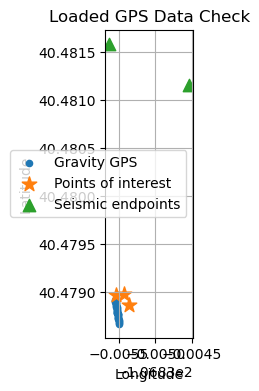

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))

gravity_gdf.plot(ax=ax, marker="o", markersize=20, label="Gravity GPS")
poi_gdf.plot(ax=ax, marker="*", markersize=120, label="Points of interest")
seismic_gdf_latlon.plot(ax=ax, marker="^", markersize=80, label="Seismic endpoints")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Loaded GPS Data Check")
ax.legend()
ax.grid(True)

plt.show()

In [20]:
gpr_folder_gopher = Path(r"../../data/GPR/raw_data/Gopher/")
gpr_folder_moose = Path(r"../../data/GPR/raw_data/Moose/")

print("Gopher folder exists:", gpr_folder_gopher.exists())
print("Moose folder exists:", gpr_folder_moose.exists())

print("\n--- Gopher files ---")
for file in gpr_folder_gopher.iterdir():
    print(file.name)

print("\n--- Moose files ---")
for file in gpr_folder_moose.iterdir():
    print(file.name)

Gopher folder exists: True
Moose folder exists: True

--- Gopher files ---
GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
GPR_group2_2026_05_25_gopher_2026-05-25_0001.time
GPR_group2_2026_05_25_gopher_2026-05-25_0001_0.iprb
GPR_group2_2026_05_25_gopher_2026-05-25_0001_0.iprh
GPR_group2_2026_05_25_gopher_2026-05-25_0001_0.mrk
GPR_group2_2026_05_25_gopher_2026-05-25_0001_1.iprb
GPR_group2_2026_05_25_gopher_2026-05-25_0001_1.iprh
GPR_group2_2026_05_25_gopher_2026-05-25_0001_1.mrk
GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
GPR_group2_2026_05_25_gopher_2026-05-25_0002.time
GPR_group2_2026_05_25_gopher_2026-05-25_0002_0.iprb
GPR_group2_2026_05_25_gopher_2026-05-25_0002_0.iprh
GPR_group2_2026_05_25_gopher_2026-05-25_0002_0.mrk
GPR_group2_2026_05_25_gopher_2026-05-25_0002_1.iprb
GPR_group2_2026_05_25_gopher_2026-05-25_0002_1.iprh
GPR_group2_2026_05_25_gopher_2026-05-25_0002_1.mrk
GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
GPR_group2_2026_05_25_gopher_2026-05-25_0003.time
GPR_grou

In [21]:
gps_extensions = [".csv", ".txt", ".gps", ".gpx", ".kml", ".cor", ".xyz"]

gpr_gps_candidates = []

for folder in [gpr_folder_gopher, gpr_folder_moose]:
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in gps_extensions:
            gpr_gps_candidates.append(file)

print("Possible GPR GPS files found:", len(gpr_gps_candidates))

for file in gpr_gps_candidates:
    print(file)

Possible GPR GPS files found: 12
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0005.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0006.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0007.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0008.cor


In [22]:
test_cor = gpr_gps_candidates[0]

print(test_cor)

with open(test_cor, "r", errors="ignore") as f:
    for i in range(20):
        print(f.readline().strip())

..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
1	2026-05-25	19:48:41:200	40.4790734300	N	106.8356877250	W	2122.13	M	4
12	2026-05-25	19:48:42:200	40.4790735833	N	106.8356886150	W	2122.15	M	4
32	2026-05-25	19:48:51:200	40.4790764650	N	106.8356905817	W	2122.12	M	4
53	2026-05-25	19:48:52:200	40.4790797517	N	106.8356922283	W	2122.08	M	4
56	2026-05-25	19:48:53:200	40.4790815317	N	106.8356926683	W	2122.05	M	4

















In [23]:
test_gpr = pd.read_csv(test_cor, sep=None, engine="python")

print(test_gpr.shape)
print(test_gpr.columns)
test_gpr.head()

(4, 10)
Index(['1', '2026-05-25', '19:48:41:200', '40.4790734300', 'N',
       '106.8356877250', 'W', '2122.13', 'M', '4'],
      dtype='object')


,1,2026-05-25,19:48:41:200,40.4790734300,N,106.8356877250,W,2122.13,M,4
0,12,2026-05-25,19:48:42:200,40.479074,N,106.835689,W,2122.15,M,4
1,32,2026-05-25,19:48:51:200,40.479076,N,106.835691,W,2122.12,M,4
2,53,2026-05-25,19:48:52:200,40.479080,N,106.835692,W,2122.08,M,4
3,56,2026-05-25,19:48:53:200,40.479082,N,106.835693,W,2122.05,M,4


In [24]:
gpr_dfs = []

for file in gpr_gps_candidates:
    temp = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=[
            "trace",
            "date",
            "time",
            "latitude",
            "lat_dir",
            "longitude",
            "lon_dir",
            "elevation_m",
            "elevation_unit",
            "quality"
        ]
    )
    
    # Add source info
    temp["source_file"] = file.name
    
    if "gopher" in file.name.lower():
        temp["gpr_device"] = "Gopher"
    else:
        temp["gpr_device"] = "Moose"
    
    # Use file stem as line name
    temp["line_name"] = file.stem
    
    gpr_dfs.append(temp)

gpr_df = pd.concat(gpr_dfs, ignore_index=True)

print("Combined GPR GPS shape:", gpr_df.shape)
gpr_df.head()

Combined GPR GPS shape: (1638, 13)


C:\Users\molly\AppData\Local\Temp\ipykernel_23676\2474596338.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gpr_df = pd.concat(gpr_dfs, ignore_index=True)


,trace,date,time,latitude,lat_dir,longitude,lon_dir,elevation_m,elevation_unit,quality,source_file,gpr_device,line_name
0,1,2026-05-25,19:48:41:200,40.479073,N,106.835688,W,2122.13,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001
1,12,2026-05-25,19:48:42:200,40.479074,N,106.835689,W,2122.15,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001
2,32,2026-05-25,19:48:51:200,40.479076,N,106.835691,W,2122.12,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001
3,53,2026-05-25,19:48:52:200,40.479080,N,106.835692,W,2122.08,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001
4,56,2026-05-25,19:48:53:200,40.479082,N,106.835693,W,2122.05,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001


In [25]:
# Convert numeric columns
gpr_df["latitude"] = pd.to_numeric(gpr_df["latitude"], errors="coerce")
gpr_df["longitude"] = pd.to_numeric(gpr_df["longitude"], errors="coerce")
gpr_df["elevation_m"] = pd.to_numeric(gpr_df["elevation_m"], errors="coerce")

# Apply hemisphere signs
gpr_df.loc[gpr_df["lat_dir"].str.upper() == "S", "latitude"] *= -1
gpr_df.loc[gpr_df["lon_dir"].str.upper() == "W", "longitude"] *= -1

# Remove bad rows
gpr_df = gpr_df.dropna(subset=["latitude", "longitude"]).copy()

print(gpr_df[["line_name", "gpr_device", "latitude", "longitude", "elevation_m"]].head())
print("Number of GPR GPS points:", len(gpr_df))

                                      line_name gpr_device   latitude  \
0  GPR_group2_2026_05_25_gopher_2026-05-25_0001     Gopher  40.479073   
1  GPR_group2_2026_05_25_gopher_2026-05-25_0001     Gopher  40.479074   
2  GPR_group2_2026_05_25_gopher_2026-05-25_0001     Gopher  40.479076   
3  GPR_group2_2026_05_25_gopher_2026-05-25_0001     Gopher  40.479080   
4  GPR_group2_2026_05_25_gopher_2026-05-25_0001     Gopher  40.479082   

    longitude  elevation_m  
0 -106.835688      2122.13  
1 -106.835689      2122.15  
2 -106.835691      2122.12  
3 -106.835692      2122.08  
4 -106.835693      2122.05  
Number of GPR GPS points: 1638


In [26]:
gpr_points_gdf = gpd.GeoDataFrame(
    gpr_df,
    geometry=gpd.points_from_xy(gpr_df["longitude"], gpr_df["latitude"]),
    crs="EPSG:4326"
)

gpr_points_gdf.head()

,trace,date,time,latitude,lat_dir,longitude,lon_dir,elevation_m,elevation_unit,quality,source_file,gpr_device,line_name,geometry
0,1,2026-05-25,19:48:41:200,40.479073,N,-106.835688,W,2122.13,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001,POINT (-106.83569 40.47907)
1,12,2026-05-25,19:48:42:200,40.479074,N,-106.835689,W,2122.15,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001,POINT (-106.83569 40.47907)
2,32,2026-05-25,19:48:51:200,40.479076,N,-106.835691,W,2122.12,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001,POINT (-106.83569 40.47908)
3,53,2026-05-25,19:48:52:200,40.479080,N,-106.835692,W,2122.08,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001,POINT (-106.83569 40.47908)
4,56,2026-05-25,19:48:53:200,40.479082,N,-106.835693,W,2122.05,M,4,GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor,Gopher,GPR_group2_2026_05_25_gopher_2026-05-25_0001,POINT (-106.83569 40.47908)


In [27]:
gpr_lines = []

for line_name, group in gpr_points_gdf.groupby("line_name"):
    group = group.sort_values("trace")
    
    if len(group) >= 2:
        line_geom = LineString(group.geometry.tolist())
        
        gpr_lines.append({
            "line_name": line_name,
            "gpr_device": group["gpr_device"].iloc[0],
            "n_points": len(group),
            "geometry": line_geom
        })

gpr_lines_gdf = gpd.GeoDataFrame(gpr_lines, crs="EPSG:4326")

print("Number of GPR lines:", len(gpr_lines_gdf))
gpr_lines_gdf[["line_name", "gpr_device", "n_points"]]

Number of GPR lines: 11


,line_name,gpr_device,n_points
0,GPR_group2_2026_05_21_2026-05-25_0001,Moose,8
1,GPR_group2_2026_05_21_2026-05-25_0002,Moose,162
2,GPR_group2_2026_05_21_2026-05-25_0003,Moose,138
3,GPR_group2_2026_05_21_2026-05-25_0004,Moose,460
4,GPR_group2_2026_05_21_2026-05-25_0005,Moose,466
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
7,GPR_group2_2026_05_25_gopher_2026-05-25_0001,Gopher,5
8,GPR_group2_2026_05_25_gopher_2026-05-25_0002,Gopher,2
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113


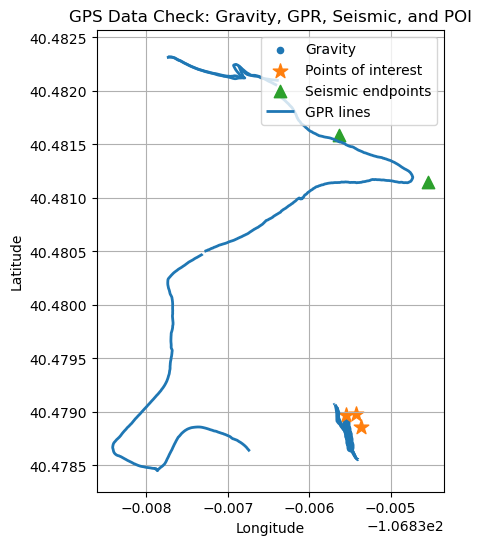

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))

gravity_gdf.plot(ax=ax, marker="o", markersize=20, label="Gravity")
poi_gdf.plot(ax=ax, marker="*", markersize=120, label="Points of interest")
seismic_gdf_latlon.plot(ax=ax, marker="^", markersize=80, label="Seismic endpoints")

gpr_lines_gdf.plot(
    ax=ax,
    linewidth=2,
    label="GPR lines"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("GPS Data Check: Gravity, GPR, Seismic, and POI")
ax.legend()
ax.grid(True)

plt.show()

In [29]:
gravity_3857 = gravity_gdf.to_crs(epsg=3857)
poi_3857 = poi_gdf.to_crs(epsg=3857)
seismic_3857 = seismic_gdf_latlon.to_crs(epsg=3857)
gpr_lines_3857 = gpr_lines_gdf.to_crs(epsg=3857)
gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

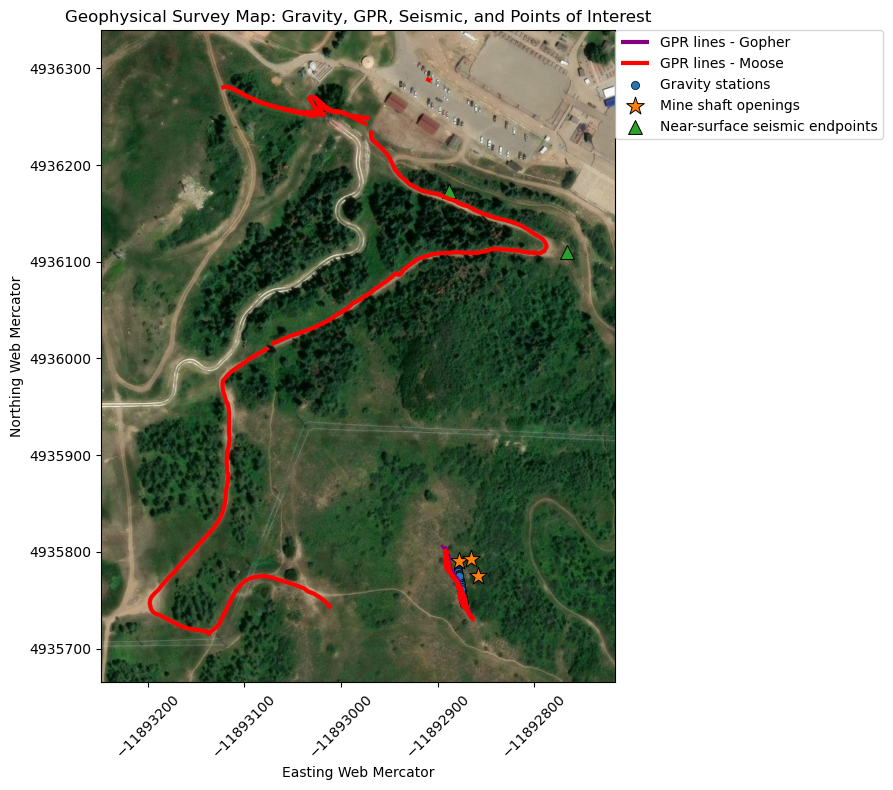

In [30]:
all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    seismic_3857[["geometry"]],
    gpr_lines_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

buffer = 50  # meters

fig, ax = plt.subplots(figsize=(8, 8))

gpr_lines_3857[gpr_lines_3857["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher"
)

gpr_lines_3857[gpr_lines_3857["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose"
)

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations"
)

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings"
)

seismic_3857.plot(
    ax=ax,
    marker="^",
    markersize=100,
    edgecolor="black",
    linewidth=0.7,
    label="Near-surface seismic endpoints"
)

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)


cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)


ax.set_title("Geophysical Survey Map: Gravity, GPR, Seismic, and Points of Interest")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
    ncol=1,
    borderaxespad=0)

# Force full coordinate values instead of 1e6 / offset notation
ax.ticklabel_format(style="plain", axis="both", useOffset=False)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

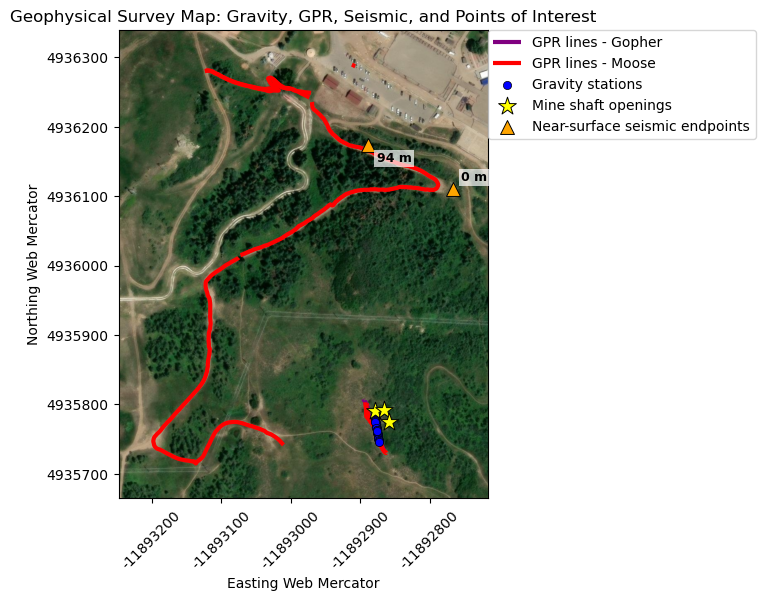

In [31]:

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    seismic_3857[["geometry"]],
    gpr_lines_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

buffer = 50  # meters

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 8))

# Set extent first
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Basemap first
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)

# GPR lines
gpr_lines_3857[gpr_lines_3857["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher",
    zorder=2
)

gpr_lines_3857[gpr_lines_3857["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose",
    zorder=2
)

# Gravity stations
gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# Mine shaft openings
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="yellow",
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings",
    zorder=5
)

# Near-surface seismic endpoints
seismic_3857.plot(
    ax=ax,
    marker="^",
    markersize=100,
    color="orange",
    edgecolor="black",
    linewidth=0.7,
    label="Near-surface seismic endpoints",
    zorder=6
)

# Label the seismic endpoints as 0 m and 94 m
for idx, row in seismic_3857.iterrows():
    station_label = f"{int(row['station_m'])} m"
    
    # Slightly different offsets so labels do not sit directly on marker
    if row["station_m"] == 0:
        offset = (6, 6)
    else:
        offset = (6, -12)
    
    ax.annotate(
        text=station_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=7
    )

# ----------------------------
# Formatting
# ----------------------------

ax.set_title("Geophysical Survey Map: Gravity, GPR, Seismic, and Points of Interest")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
    ncol=1,
    borderaxespad=0
)

# Force full coordinate values
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [38]:
# ----------------------------
# Select GPR lines for final map
# ----------------------------

selected_gpr_lines = gpr_lines_3857[
    (
        (gpr_lines_3857["gpr_device"] == "Gopher") &
        (gpr_lines_3857["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_3857["gpr_device"] == "Moose") &
        (gpr_lines_3857["line_name"].str.endswith(("0007", "0008")))
    )
].copy()

print("Selected GPR lines:")
display(selected_gpr_lines[["line_name", "gpr_device", "n_points"]])

Selected GPR lines:


,line_name,gpr_device,n_points
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113
10,GPR_group2_2026_05_25_gopher_2026-05-25_0004,Gopher,65


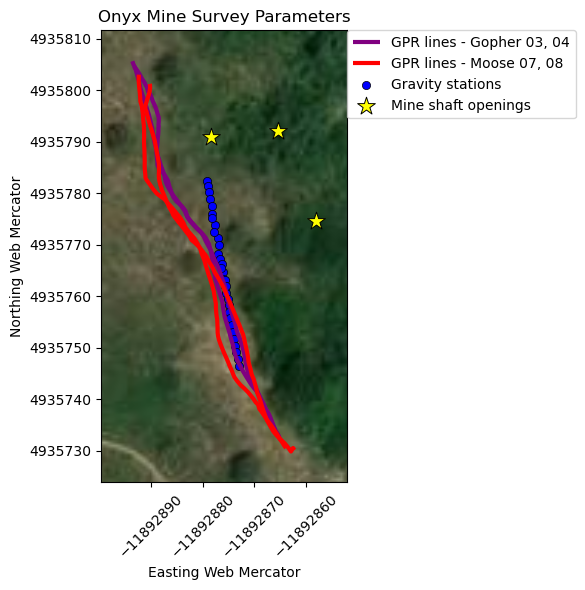

In [39]:
# ----------------------------
# Set map extent using gravity + selected GPR lines + points of interest
# ----------------------------

all_layers_gravity_gpr = pd.concat([
    gravity_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    poi_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers_gravity_gpr.total_bounds

buffer = 6  # meters; increase if map is too tight

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# GPR lines
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04"
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08"
)

# Gravity stations
gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations"
)

# Points of interest
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="yellow",
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings"
)

# Map extent
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Satellite basemap
# No crs argument because all layers are already EPSG:3857
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)

# Formatting
ax.set_title("Onyx Mine Survey Parameters")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
    ncol=1,
    borderaxespad=0)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
# ----------------------------
# Create start/end points for selected GPR lines
# ----------------------------

gpr_endpoint_rows = []

for idx, row in selected_gpr_lines.iterrows():
    coords = list(row.geometry.coords)
    
    start_point = Point(coords[0])
    end_point = Point(coords[-1])
    
    # Pull short line number from filename: 0003 -> 03, etc.
    line_num = row["line_name"].split("_")[-1]
    short_line_num = line_num[-2:]
    
    gpr_endpoint_rows.append({
        "line_name": row["line_name"],
        "line_id": short_line_num,
        "gpr_device": row["gpr_device"],
        "endpoint": "start",
        "geometry": start_point
    })
    
    gpr_endpoint_rows.append({
        "line_name": row["line_name"],
        "line_id": short_line_num,
        "gpr_device": row["gpr_device"],
        "endpoint": "end",
        "geometry": end_point
    })

gpr_endpoints_3857 = gpd.GeoDataFrame(
    gpr_endpoint_rows,
    geometry="geometry",
    crs=selected_gpr_lines.crs
)

gpr_endpoints_3857

,line_name,line_id,gpr_device,endpoint,geometry
0,GPR_group2_2026_05_21_2026-05-25_0007,07,Moose,start,POINT (-11892890.286 4935801.244)
1,GPR_group2_2026_05_21_2026-05-25_0007,07,Moose,end,POINT (-11892862.215 4935730.167)
2,GPR_group2_2026_05_21_2026-05-25_0008,08,Moose,start,POINT (-11892863.848 4935730.558)
3,GPR_group2_2026_05_21_2026-05-25_0008,08,Moose,end,POINT (-11892892.42 4935803.025)
4,GPR_group2_2026_05_25_gopher_2026-05-25_0003,03,Gopher,start,POINT (-11892893.681 4935805.633)
5,GPR_group2_2026_05_25_gopher_2026-05-25_0003,03,Gopher,end,POINT (-11892864.913 4935732.134)
6,GPR_group2_2026_05_25_gopher_2026-05-25_0004,04,Gopher,start,POINT (-11892865.212 4935732.769)
7,GPR_group2_2026_05_25_gopher_2026-05-25_0004,04,Gopher,end,POINT (-11892893.323 4935804.623)


Highlighted gravity stations:


,station,station_num,geometry
0,29.0,29.0,POINT (-11892879.201 4935782.386)
12,15.0,15.0,POINT (-11892876.167 4935764.777)
26,1.0,1.0,POINT (-11892872.895 4935746.465)


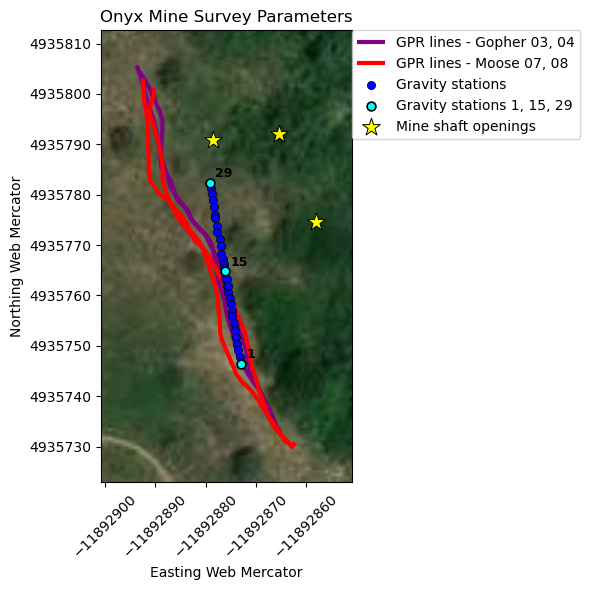

In [41]:

buffer = 7
highlight_marker_size = 40
highlight_label_size = 9

# ----------------------------
# Select gravity stations to highlight
# ----------------------------

# Find the correct gravity station column
if "station" in gravity_3857.columns:
    gravity_station_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_station_col = "Name"
else:
    raise ValueError("Could not find gravity station column. Check gravity_3857.columns")

# Convert station values to numeric so 1.0 matches 1
gravity_3857["station_num"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)

highlight_gravity = gravity_3857[
    gravity_3857["station_num"].isin([1, 15, 29])
].copy()

print("Highlighted gravity stations:")
display(highlight_gravity[[gravity_station_col, "station_num", "geometry"]])

# ----------------------------
# Set map extent
# ----------------------------

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    highlight_gravity[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Map extent first
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Satellite basemap first
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)

# GPR lines - Gopher
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

# GPR lines - Moose
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

# All gravity stations
gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# Highlight gravity stations 1, 15, and 29
highlight_gravity.plot(
    ax=ax,
    marker="o",
    markersize=highlight_marker_size,
    color="cyan",
    edgecolor="black",
    linewidth=1.2,
    label="Gravity stations 1, 15, 29",
    zorder=6
)

# Label highlighted gravity stations
for idx, row in highlight_gravity.iterrows():
    ax.annotate(
        text=str(int(row["station_num"])),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=highlight_label_size,
        color="black",
        fontweight="bold",
        zorder=7
    )

# Mine shaft openings / points of interest
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="yellow",
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings",
    zorder=5
)

# ----------------------------
# Formatting
# ----------------------------

ax.set_title("Onyx Mine Survey Parameters")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

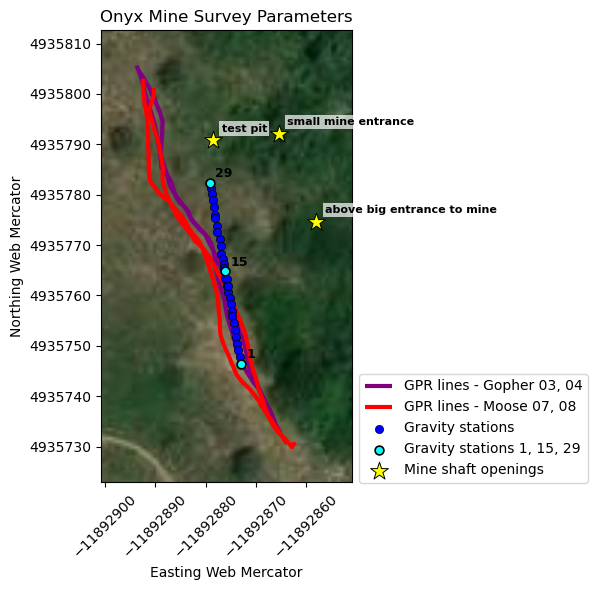

In [42]:

# ----------------------------
# Adjustable settings
# ----------------------------

buffer = 7
highlight_marker_size = 40
highlight_label_size = 9
poi_label_size = 8

# ----------------------------
# Select gravity stations to highlight
# ----------------------------

# Find the correct gravity station column
if "station" in gravity_3857.columns:
    gravity_station_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_station_col = "Name"
else:
    raise ValueError("Could not find gravity station column. Check gravity_3857.columns")

# Convert station values to numeric so 1.0 matches 1
gravity_3857["station_num"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)

highlight_gravity = gravity_3857[
    gravity_3857["station_num"].isin([1, 15, 29])
].copy()

# ----------------------------
# Set map extent
# ----------------------------

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    highlight_gravity[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Map extent first
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Satellite basemap first
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)

# GPR lines - Gopher
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

# GPR lines - Moose
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

# All gravity stations
gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# Highlight gravity stations 1, 15, and 29
highlight_gravity.plot(
    ax=ax,
    marker="o",
    markersize=highlight_marker_size,
    color="cyan",
    edgecolor="black",
    linewidth=1.2,
    label="Gravity stations 1, 15, 29",
    zorder=6
)

# Label highlighted gravity stations
for idx, row in highlight_gravity.iterrows():
    ax.annotate(
        text=str(int(row["station_num"])),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=highlight_label_size,
        color="black",
        fontweight="bold",
        zorder=7
    )

# Mine shaft openings / points of interest
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="yellow",
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings",
    zorder=5
)

# Label each mine shaft opening
for idx, row in poi_3857.iterrows():
    ax.annotate(
        text=row["point_name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=poi_label_size,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=8
    )

# ----------------------------
# Formatting
# ----------------------------

ax.set_title("Onyx Mine Survey Parameters")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.03, 0.24),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [43]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# --------------------------------------------------
# 1. Near-surface seismic endpoints
# --------------------------------------------------
# Uses your updated seismic endpoints in UTM Zone 13N / EPSG:32613

seismic_endpoints = pd.DataFrame({
    "station_m": [0, 94],
    "easting": [344505, 344413.41],
    "northing": [4482779, 4482829.22],
    "utm_zone": ["13T", "13T"]
})

seismic_gdf = gpd.GeoDataFrame(
    seismic_endpoints,
    geometry=gpd.points_from_xy(seismic_endpoints["easting"], seismic_endpoints["northing"]),
    crs="EPSG:32613"
)

# Convert seismic points to same CRS as GPR GPS points
seismic_gdf_latlon = seismic_gdf.to_crs(epsg=4326)
seismic_3857 = seismic_gdf.to_crs(epsg=3857)

print("Seismic endpoints lat/lon:")
display(seismic_gdf_latlon)


# --------------------------------------------------
# 2. Use nearest GPR GPS elevation for each seismic endpoint
# --------------------------------------------------
# Requires gpr_points_gdf from earlier GPR loading code.
# gpr_points_gdf should have: latitude, longitude, elevation_m, gpr_device, line_name

gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

nearest_gpr_elevations = []

for idx, seis_row in seismic_3857.iterrows():
    distances = gpr_points_3857.geometry.distance(seis_row.geometry)
    nearest_idx = distances.idxmin()
    nearest_gpr = gpr_points_3857.loc[nearest_idx]
    
    nearest_gpr_elevations.append({
        "seismic_station_m": seis_row["station_m"],
        "seismic_easting": seis_row["easting"],
        "seismic_northing": seis_row["northing"],
        "nearest_gpr_device": nearest_gpr["gpr_device"],
        "nearest_gpr_line": nearest_gpr["line_name"],
        "nearest_gpr_elevation_m": nearest_gpr["elevation_m"],
        "distance_to_nearest_gpr_point_m": distances.loc[nearest_idx]
    })

nearest_gpr_elevations_df = pd.DataFrame(nearest_gpr_elevations)

print("Nearest GPR-derived elevations for seismic endpoints:")
display(nearest_gpr_elevations_df)


# --------------------------------------------------
# 3. Gravity station 1 elevation
# --------------------------------------------------
# Requires gravity_3857 or gravity_gdf from earlier.
# Your gravity file had an elevation column renamed to elevation_m.

gravity_station_1 = gravity_3857[
    pd.to_numeric(gravity_3857["station"], errors="coerce") == 1
].copy()

print("Gravity station 1:")
display(gravity_station_1[["station", "elevation_m", "geometry"]])

Seismic endpoints lat/lon:


,station_m,easting,northing,utm_zone,geometry
0,0,344505.00,4482779.00,13T,POINT (-106.83454 40.48115)
1,94,344413.41,4482829.22,13T,POINT (-106.83563 40.48159)


Nearest GPR-derived elevations for seismic endpoints:


,seismic_station_m,seismic_easting,seismic_northing,nearest_gpr_device,nearest_gpr_line,nearest_gpr_elevation_m,distance_to_nearest_gpr_point_m
0,0,344505.00,4482779.00,Moose,GPR_group2_2026_05_21_2026-05-25_0004,2076.0,22.045779
1,94,344413.41,4482829.22,Moose,GPR_group2_2026_05_21_2026-05-25_0004,2067.9,8.382921


Gravity station 1:


,station,elevation_m,geometry
26,1.0,2112.468,POINT (-11892872.895 4935746.465)


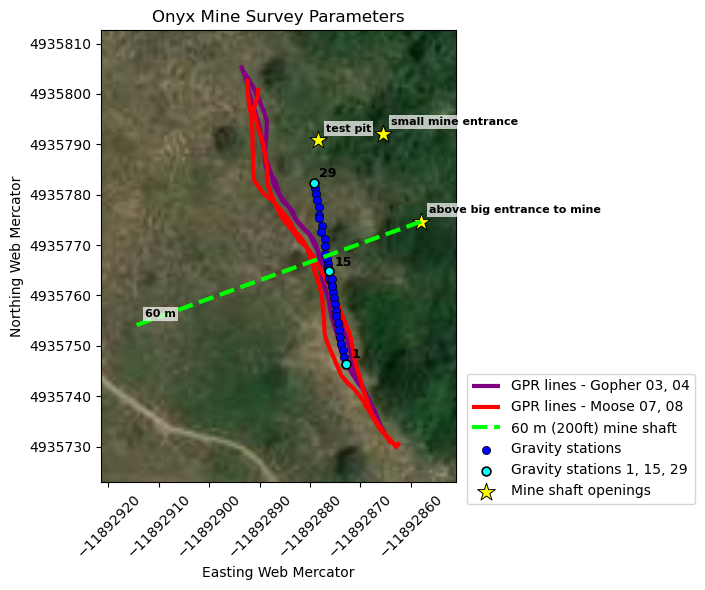

In [48]:

# ----------------------------
# Adjustable settings
# ----------------------------

buffer = 7
highlight_marker_size = 40
highlight_label_size = 9
poi_label_size = 8

mine_line_length_m = 60
mine_line_azimuth_deg = 250   # clockwise from north

# ----------------------------
# Select gravity stations to highlight
# ----------------------------

if "station" in gravity_3857.columns:
    gravity_station_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_station_col = "Name"
else:
    raise ValueError("Could not find gravity station column. Check gravity_3857.columns")

gravity_3857["station_num"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)

highlight_gravity = gravity_3857[
    gravity_3857["station_num"].isin([1, 15, 29])
].copy()

# ----------------------------
# Create 60 m line from "above big entrance to mine"
# ----------------------------

start_poi = poi_3857[
    poi_3857["point_name"].str.lower().str.strip() == "above big entrance to mine"
].copy()

if len(start_poi) != 1:
    raise ValueError("Could not find exactly one point named 'above big entrance to mine'.")

start_geom = start_poi.geometry.iloc[0]
x0 = start_geom.x
y0 = start_geom.y

# Azimuth convention: 0 = north, 90 = east, 180 = south, 270 = west
theta = np.deg2rad(mine_line_azimuth_deg)

dx = mine_line_length_m * np.sin(theta)
dy = mine_line_length_m * np.cos(theta)

x1 = x0 + dx
y1 = y0 + dy

mine_projection_line = gpd.GeoDataFrame(
    {
        "name": ["60 m projection from big entrance"],
        "length_m": [mine_line_length_m],
        "azimuth_deg": [mine_line_azimuth_deg]
    },
    geometry=[LineString([(x0, y0), (x1, y1)])],
    crs=poi_3857.crs
)

# Optional endpoint point
mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "name": ["60 m endpoint"]
    },
    geometry=[gpd.points_from_xy([x1], [y1])[0]],
    crs=poi_3857.crs
)

# ----------------------------
# Set map extent
# ----------------------------

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    highlight_gravity[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Map extent first
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Satellite basemap first
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18,
    attribution=False
)

# GPR lines - Gopher
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

# GPR lines - Moose
selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

# 60 m projected mine line
mine_projection_line.plot(
    ax=ax,
    linewidth=3,
    color="lime",
    linestyle="--",
    label="60 m (200ft) mine shaft",
    zorder=6
)


# All gravity stations
gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# Highlight gravity stations 1, 15, and 29
highlight_gravity.plot(
    ax=ax,
    marker="o",
    markersize=highlight_marker_size,
    color="cyan",
    edgecolor="black",
    linewidth=1.2,
    label="Gravity stations 1, 15, 29",
    zorder=6
)

# Label highlighted gravity stations
for idx, row in highlight_gravity.iterrows():
    ax.annotate(
        text=str(int(row["station_num"])),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=highlight_label_size,
        color="black",
        fontweight="bold",
        zorder=7
    )

# Mine shaft openings / points of interest
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="yellow",
    edgecolor="black",
    linewidth=0.7,
    label="Mine shaft openings",
    zorder=5
)

# Label each mine shaft opening
for idx, row in poi_3857.iterrows():
    ax.annotate(
        text=row["point_name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=poi_label_size,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=8
    )

# Label projected endpoint
for idx, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text="60 m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=8
    )

# ----------------------------
# Formatting
# ----------------------------

ax.set_title("Onyx Mine Survey Parameters")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.03, 0.24),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()